# Pipeline simples (Google Colab) — Marcha com marcadores (calcanhar e dedo)

Este notebook foi feito para atividades do **ImpaTech**.

Objetivo: carregar um arquivo CSV com trajetórias 3D (x, y, z), remover valores faltantes (NaN) e fazer gráficos
para ajudar a **visualizar** e **identificar eventos** (por exemplo, *heel strike* / toque do calcanhar) em etapas posteriores.

**Formato esperado do CSV** (colunas):
- `t` (tempo em segundos)
- `LHEE_x, LHEE_y, LHEE_z` (calcanhar esquerdo)
- `LTOE_x, LTOE_y, LTOE_z` (dedo esquerdo)
- `RHEE_x, RHEE_y, RHEE_z` (calcanhar direito)
- `RTOE_x, RTOE_y, RTOE_z` (dedo direito)

> Dica: esse CSV pode ser exportado do MATLAB.

## 0) Bibliotecas

Vamos usar:
- `pandas` para ler e organizar dados
- `numpy` para contas básicas
- `matplotlib` para gráficos

> Se você for detectar eventos automaticamente (picos/vales), `scipy` ajuda, mas aqui deixamos **opcional**.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1) Carregar arquivo (upload no Colab)

No Colab, o jeito mais simples é fazer upload do CSV.
Depois disso, o arquivo fica disponível pelo nome `fname`.

Se você tiver vários arquivos para comparar no futuro, você pode repetir o upload e ler cada um.

In [139]:
df = pd.read_csv("C:\\Users\\Pedro\\Documents\\GitHub\\estudo\\prog_impatech\\Aplic_Med\\controle1.csv") #carrega o arquivo de controle
cerebelar = pd.read_csv("C:\\Users\\Pedro\\Documents\\GitHub\\estudo\\prog_impatech\\Aplic_Med\\Cerebelar_Ataxia.csv") #carrega o arquivo de ataxia cerebelar
PD_OFF = pd.read_csv("C:\\Users\\Pedro\\Documents\\GitHub\\estudo\\prog_impatech\\Aplic_Med\\PD_OFF.csv")
PD_ON = pd.read_csv("C:\\Users\\Pedro\\Documents\\GitHub\\estudo\\prog_impatech\\Aplic_Med\\PD_ON.csv")

df.head(), df.shape

(          t  LHEE_x  LHEE_y  LHEE_z       LTOE_x       LTOE_y     LTOE_z  \
 0  0.000000     NaN     NaN     NaN  2531.440918  1078.940308  43.818325   
 1  0.016667     NaN     NaN     NaN  2467.478027  1080.191406  49.003769   
 2  0.033333     NaN     NaN     NaN  2405.838623  1082.033569  55.434456   
 3  0.050000     NaN     NaN     NaN  2348.609131  1084.675781  63.633610   
 4  0.066667     NaN     NaN     NaN  2297.498291  1087.925781  73.018303   
 
    RHEE_x  RHEE_y  RHEE_z  RTOE_x  RTOE_y  RTOE_z  
 0     NaN     NaN     NaN     NaN     NaN     NaN  
 1     NaN     NaN     NaN     NaN     NaN     NaN  
 2     NaN     NaN     NaN     NaN     NaN     NaN  
 3     NaN     NaN     NaN     NaN     NaN     NaN  
 4     NaN     NaN     NaN     NaN     NaN     NaN  ,
 (253, 13))

## 2) Remover NaNs (valores faltantes)

NaNs podem aparecer por falhas de captura, oclusões, etc.

Há duas estratégias simples:
1. **Remover linhas com NaN** (mais simples, mas pode perder dados)
2. **Interpolar** (preenche NaNs usando valores vizinhos)

Aqui vamos começar pela opção mais simples (remover).

In [330]:
# Quantos NaNs por coluna?

Nans_Matrix = pd.DataFrame({
    'controle': df.isna().sum(),
    'cerebelar': cerebelar.isna().sum(),
    'PD_OFF': PD_OFF.isna().sum(),
    'PD_ON': PD_ON.isna().sum()
})

Percentual_Nans_Matrix = pd.DataFrame({
    'controle': df.isna().sum() / df.shape[0],
    'cerebelar': cerebelar.isna().sum() / cerebelar.shape[0],
    'PD_OFF': PD_OFF.isna().sum() / PD_OFF.shape[0],
    'PD_ON': PD_ON.isna().sum() / PD_ON.shape[0]
})

Max_Nans_Matrix = pd.Series({
    'controle': df.isna().any(axis=1).sum() / df.shape[0],
    'Cerebelar': cerebelar.isna().any(axis=1).sum() / cerebelar.shape[0],
    'PD_OFF': PD_OFF.isna().any(axis=1).sum() / PD_OFF.shape[0],
    'PD_ON': PD_ON.isna().any(axis=1).sum() / PD_ON.shape[0]
})


Nans_Matrix, Percentual_Nans_Matrix, Max_Nans_Matrix, 

(        controle  cerebelar  PD_OFF  PD_ON
 t              0          0       0      0
 LHEE_x        55          3      22     19
 LHEE_y        55          3      22     19
 LHEE_z        55          3      22     19
 LTOE_x         1          1       4      4
 LTOE_y         1          1       4      4
 LTOE_z         1          1       4      4
 RHEE_x        32          1      11     20
 RHEE_y        32          1      11     20
 RHEE_z        32          1      11     20
 RTOE_x        44          3      21      3
 RTOE_y        44          3      21      3
 RTOE_z        44          3      21      3,
         controle  cerebelar    PD_OFF     PD_ON
 t       0.000000   0.000000  0.000000  0.000000
 LHEE_x  0.217391   0.008380  0.068536  0.066202
 LHEE_y  0.217391   0.008380  0.068536  0.066202
 LHEE_z  0.217391   0.008380  0.068536  0.066202
 LTOE_x  0.003953   0.002793  0.012461  0.013937
 LTOE_y  0.003953   0.002793  0.012461  0.013937
 LTOE_z  0.003953   0.002793  0.012461  

In [331]:
# Opção A: remover qualquer linha que tenha NaN
df_clean = df.dropna().reset_index(drop=True)

print("Linhas antes:", len(df), "| depois:", len(df_clean))
df_clean.head()

Linhas antes: 253 | depois: 178


,t,LHEE_x,LHEE_y,LHEE_z,LTOE_x,LTOE_y,LTOE_z,RHEE_x,RHEE_y,RHEE_z,RTOE_x,RTOE_y,RTOE_z
0,0.916667,1984.995239,1115.742798,246.296478,1859.858887,1116.308105,68.624641,1668.931641,1252.981567,41.630890,1454.638184,1281.118042,34.728283
1,0.933333,1937.727783,1121.564087,230.366592,1799.795166,1116.201172,66.792145,1669.099731,1252.420166,42.098629,1454.714600,1281.166138,34.659595
2,0.950000,1889.245850,1126.996338,212.864456,1736.197754,1116.290771,63.233070,1669.786865,1251.972656,42.576324,1454.817383,1281.152588,34.595032
3,0.966667,1838.395874,1131.889282,192.907257,1669.955933,1116.257446,58.646202,1670.922119,1251.855225,43.083977,1454.906006,1281.108521,34.512409
4,0.983333,1784.322632,1136.280762,170.579529,1601.890747,1115.894043,53.675430,1672.044678,1252.080078,43.620609,1455.001465,1281.104492,34.343941


### (Opcional) Interpolação em vez de remover

Se o arquivo tiver muitos NaNs, remover pode apagar grande parte do sinal.
Nesse caso, a interpolação pode ajudar.

Se quiser usar interpolação, descomente e use `df_use = df_interp`.

In [332]:
# --- Opcional: interpolar ---
df_interp = df.copy()
numeric_cols = df_interp.select_dtypes(include=[np.number]).columns
df_interp[numeric_cols] = df_interp[numeric_cols].interpolate(limit_direction="both")
df_interp = df_interp.dropna().reset_index(drop=True)
print("Linhas após interpolação:", len(df_interp))

Linhas após interpolação: 253


A partir daqui, vamos usar `df_use` como a versão "limpa" do dataset.

In [333]:
df_use = df_clean  # troque para df_interp se você estiver usando interpolação

## 3) Plotar a trajetória do calcanhar e do dedo no mesmo gráfico

Para visualização de marcha, é comum olhar o eixo **z** (altura) para identificar padrões.

Aqui vamos plotar **pé esquerdo**:
- calcanhar: `LHEE_z`
- dedo/toe: `LTOE_z`

> Se quiser o pé direito, troque `L...` por `R...`.

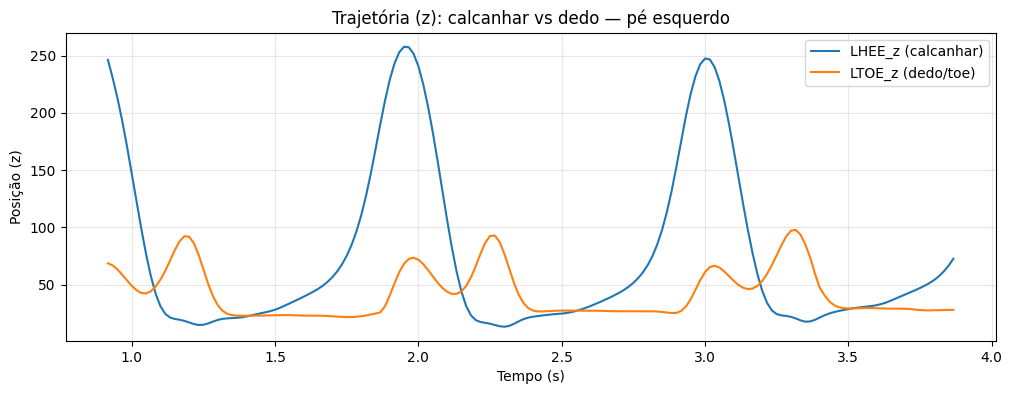

In [334]:
t = df_use["t"].to_numpy()

heel_z = df_use["LHEE_z"].to_numpy()
toe_z  = df_use["LTOE_z"].to_numpy()

plt.figure(figsize=(12,4))
plt.plot(t, heel_z, label="LHEE_z (calcanhar)")
plt.plot(t, toe_z,  label="LTOE_z (dedo/toe)")
plt.xlabel("Tempo (s)")
plt.ylabel("Posição (z)")
plt.title("Trajetória (z): calcanhar vs dedo — pé esquerdo")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 4) Plotar somente 'toques' (visualização)

Nesta atividade, vamos fazer algo **bem simples**: marcar candidatos a "toque do calcanhar" como **mínimos locais** do sinal `LHEE_z`.
Uma forma prática de encontrar mínimos locais é buscar picos em `-LHEE_z`.

> Observação: esse método é só um começo didático. Depois vocês podem melhorar (filtros, regras, validação).

### 4.1 Estimar a frequência de amostragem (ajuda a escolher parâmetros)

In [335]:
dt = np.median(np.diff(t))
fs = 1/dt if dt > 0 else np.nan
print(f"dt ~ {dt:.4f} s | fs ~ {fs:.2f} Hz")

dt ~ 0.0167 s | fs ~ 60.00 Hz


### 4.2 Detectar mínimos locais usando SciPy (opcional, mas prático)

Se `scipy` não estiver disponível, dá para instalar com:
```
!pip -q install scipy
```

Vamos usar:
- `distance`: tempo mínimo entre eventos (em segundos) → convertido para amostras
- `prominence`: quão "forte" precisa ser o mínimo (evita ruído)

In [336]:
# Se precisar instalar, descomente a linha abaixo:
# !pip -q install scipy

from scipy.signal import find_peaks

min_time_between_events = 0.4  # segundos (ajuste se necessário)
distance = int(min_time_between_events / dt)

inv = -heel_z
peaks, props = find_peaks(inv, distance=distance, prominence=np.std(inv)*0.3)

print("Número de 'toques' detectados:", len(peaks))

Número de 'toques' detectados: 3


### 4.3 Gráfico do calcanhar com marcação dos 'toques'

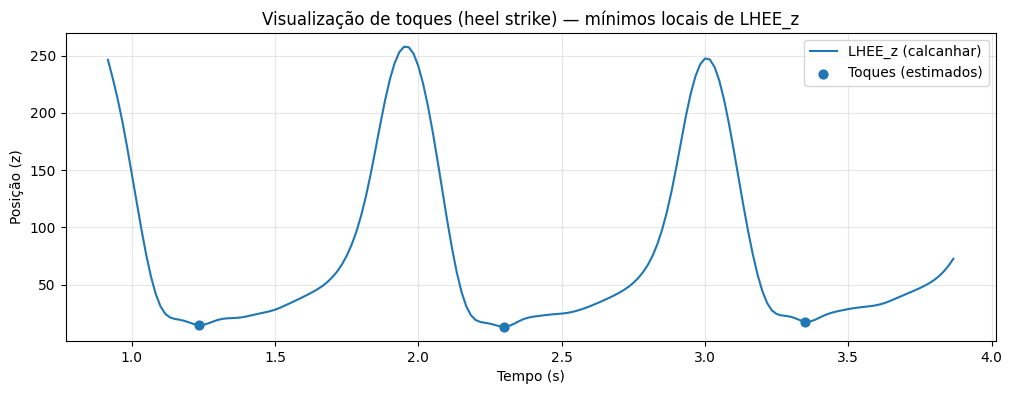

In [337]:
plt.figure(figsize=(12,4))
plt.plot(t, heel_z, label="LHEE_z (calcanhar)")
plt.scatter(t[peaks], heel_z[peaks], s=40, label="Toques (estimados)")
plt.xlabel("Tempo (s)")
plt.ylabel("Posição (z)")
plt.title("Visualização de toques (heel strike) — mínimos locais de LHEE_z")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 5) Detectar retirada do pé do chão (Toe-off)

Nesta etapa, vamos identificar a retirada do pé do chão, também chamada de toe-off (TO).

Na marcha humana, o toe-off acontece quando o dedo do pé perde contato com o solo, marcando o final da fase de apoio e o início da fase de balanço.

Ideia principal (simplificada)

O marcador do dedo do pé (LTOE) descreve um movimento vertical ao longo do tempo.

Próximo ao instante de retirada do pé, o dedo costuma estar em uma posição mais baixa antes de começar a subir.

Portanto, assim como fizemos para o toque do calcanhar, podemos aproximar o toe-off como um mínimo local do sinal LTOE_z.

⚠️ Importante:
Este é um método aproximado e didático, usado aqui para fins de aprendizagem.
Em estudos avançados, outros critérios podem ser usados (velocidade, aceleração, força de reação do solo, etc.).

> Adicionar aspas



Estratégia adotada

Usar o sinal LTOE_z (posição vertical do dedo do pé).

Inverter o sinal (-LTOE_z) para transformar mínimos em picos.

Detectar esses picos como candidatos a toe-off.

Visualizar os eventos no gráfico para verificar se fazem sentido.

Essa abordagem permite:

entender a relação entre movimento biomecânico e sinal temporal;

visualizem claramente onde o algoritmo está identificando os eventos;

ajustem parâmetros e discutam limitações do método.

#### 5.1 Detectar “toe-off” como mínimos locais do dedo (LTOE_z)

In [338]:
# ===== Pé esquerdo: retirar do chão (Toe-off) como "início da subida" do toe =====
# Ideia didática:
# 1) Dentro de um ciclo do MESMO pé (entre dois HS consecutivos), o toe (LTOE_z) fica baixo durante o apoio.
# 2) Toe-off (TO) acontece na transição apoio → balanço, quando o toe começa a subir.
# 3) Então: achamos o mínimo do toe e marcamos o PRIMEIRO ponto em que o toe sobe "delta_up" acima desse mínimo.

toe_z = df_use["LTOE_z"].to_numpy()

delta_up = 5.0        # quanto o toe precisa subir acima do mínimo (ajuste 3–15 dependendo das unidades)
max_search_s = 0.8     # janela máxima (s) após o mínimo para achar a subida
max_search = int(max_search_s / dt)

def detect_to_in_window(toe_signal, a, b):
    """Retorna um índice de TO dentro da janela [a, b) usando:
    mínimo do toe + primeiro ponto que sobe delta_up."""
    if b - a < 5:
        return None

    seg = toe_signal[a:b]

    # 1) mínimo (toe baixo durante o apoio)
    m_rel = np.argmin(seg)
    m = a + m_rel
    min_val = toe_signal[m]

    # 2) procurar início da subida após o mínimo
    start = m
    end = min(b, m + max_search)

    for k in range(start, end):
        if toe_signal[k] >= min_val + delta_up:
            return k

    # fallback: se não achou subida clara, retorna o mínimo
    return m

# HS do pé esquerdo já foi calculado no item 4 como "peaks"
hs_L_idx = peaks

# TO do pé esquerdo (inclui início, janelas internas e final)
to_L_idx = []

# (A) janela inicial: começo → primeiro HS (opcional)
if len(hs_L_idx) > 0:
    to0 = detect_to_in_window(toe_z, 0, hs_L_idx[0])
    if to0 is not None:
        to_L_idx.append(to0)

# (B) janelas internas: HS[i] → HS[i+1]
for i in range(len(hs_L_idx) - 1):
    a, b = hs_L_idx[i], hs_L_idx[i+1]
    toi = detect_to_in_window(toe_z, a, b)
    if toi is not None:
        to_L_idx.append(toi)

# (C) janela final: último HS → fim do sinal
if len(hs_L_idx) > 0:
    to_last = detect_to_in_window(toe_z, hs_L_idx[-1], len(toe_z))
    if to_last is not None:
        to_L_idx.append(to_last)

to_L_idx = np.array(to_L_idx, dtype=int)
print("Toe-offs (TO) estimados (pé esquerdo):", len(to_L_idx))


Toe-offs (TO) estimados (pé esquerdo): 4


####5.2 Plotar toe-off no gráfico do dedo

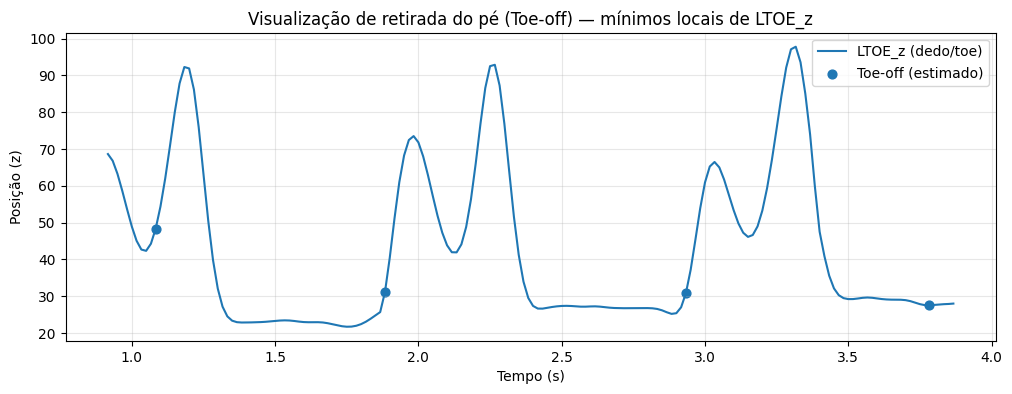

In [339]:
plt.figure(figsize=(12,4))
plt.plot(t, toe_z, label="LTOE_z (dedo/toe)")
plt.scatter(t[to_L_idx], toe_z[to_L_idx], s=40, label="Toe-off (estimado)")
plt.xlabel("Tempo (s)")
plt.ylabel("Posição (z)")
plt.title("Visualização de retirada do pé (Toe-off) — mínimos locais de LTOE_z")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


####5.3 Plotar toque (heel strike) e toe-off juntos (mesmo gráfico)

Essa figura ajuda a visualizar a relação entre o marcador do calcanhar e da ponta do pé

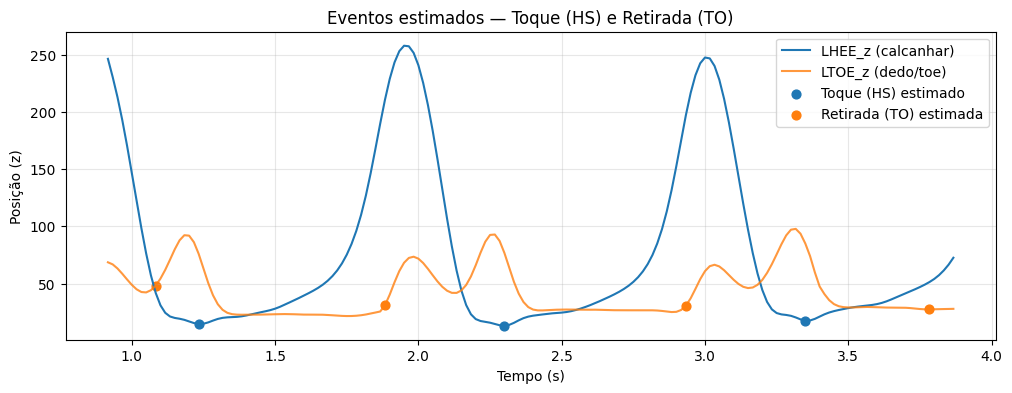

In [340]:
plt.figure(figsize=(12,4))
plt.plot(t, heel_z, label="LHEE_z (calcanhar)")
plt.plot(t, toe_z,  label="LTOE_z (dedo/toe)", alpha=0.8)

plt.scatter(t[peaks], heel_z[peaks], s=40, label="Toque (HS) estimado")
plt.scatter(t[to_L_idx], toe_z[to_L_idx], s=40, label="Retirada (TO) estimada")

plt.xlabel("Tempo (s)")
plt.ylabel("Posição (z)")
plt.title("Eventos estimados — Toque (HS) e Retirada (TO)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


###5.4 (Opcional, mas útil) Garantir ordem fisiológica: HS antes de TO

Em marcha normal, a sequência em um ciclo (mesmo pé) é:

HS → TO → HS → TO …

Então dá pra fazer um filtro simples: para cada HS, pegar o primeiro TO depois dele.

In [341]:
# ===== Parear eventos (pé esquerdo) na ordem fisiológica: HS → TO =====
# Ideia didática:
# Para cada HS, escolhemos o PRIMEIRO TO que acontece depois dele e antes do próximo HS (mesmo pé).

hs_idx = hs_L_idx
to_idx = to_L_idx

paired_hs_L = []
paired_to_L = []

for i in range(len(hs_idx) - 1):
    hs_i = hs_idx[i]
    hs_next = hs_idx[i + 1]

    # TOs candidatos entre dois HS consecutivos
    candidates = to_idx[(to_idx > hs_i) & (to_idx < hs_next)]
    if len(candidates) > 0:
        paired_hs_L.append(hs_i)
        paired_to_L.append(candidates[0])

paired_hs_L = np.array(paired_hs_L, dtype=int)
paired_to_L = np.array(paired_to_L, dtype=int)

print("Pares HS→TO (pé esquerdo):", len(paired_hs_L))

# (compatibilidade com células antigas do notebook)
paired_hs = paired_hs_L
paired_to = paired_to_L


Pares HS→TO (pé esquerdo): 2


##6) Contato e retirada do pé direito (RHEE / RTOE)

Até aqui, identificamos os eventos de marcha (toque do calcanhar e retirada do pé) para o pé esquerdo, usando os sinais verticais dos marcadores LHEE (calcanhar) e LTOE (dedo).

Neste bloco, vamos aplicar exatamente a mesma lógica para o pé direito, utilizando:

- RHEE_z → calcanhar direito

- RTOE_z → dedo direito

O objetivo é determinar:

- Contato do pé direito com o solo (heel strike direito), e

- Retirada do pé direito do solo (toe-off direito).

A ideia é manter o código simples e consistente, facilitando a comparação entre os dois lados.

Estratégia adotada (igual ao lado esquerdo)

- Usar o sinal vertical (z) do calcanhar para identificar toques como mínimos locais.

- Usar o sinal vertical (z) do dedo para identificar retiradas como mínimos locais.

Garantir que os eventos ocorram em uma ordem fisiologicamente plausível (toque → retirada).

In [342]:
# sinais do pé direito
heel_z_R = df_use["RHEE_z"].to_numpy()
toe_z_R  = df_use["RTOE_z"].to_numpy()

# -------------------------------------------------
# 1) Toque do calcanhar direito (Heel Strike - HS)
# -------------------------------------------------
inv_heel_R = -heel_z_R

hs_R_idx, _ = find_peaks(
    inv_heel_R,
    distance=distance,
    prominence=np.std(inv_heel_R)*0.3
)

print("Toques do pé direito (HS) detectados:", len(hs_R_idx))

# -------------------------------------------------
# 2) Retirada do pé direito (Toe-off - TO)
#     como 'início da subida' do toe
# -------------------------------------------------
to_R_idx = []

delta_up = 5.0        # quanto o toe precisa subir acima do mínimo (ajuste 3–15)
max_search_s = 0.8    # janela máxima após o mínimo para achar a subida
max_search = int(max_search_s / dt)

def detect_to_in_window(a, b):
    """Retorna um índice TO dentro da janela [a, b) usando:
       mínimo do toe + primeiro ponto que sobe delta_up."""
    if b - a < 5:
        return None

    seg = toe_z_R[a:b]
    m_rel = np.argmin(seg)
    m = a + m_rel
    min_val = toe_z_R[m]

    start = m
    end = min(b, m + max_search)

    for k in range(start, end):
        if toe_z_R[k] >= min_val + delta_up:
            return k

    # fallback: se não achar subida clara, retorna o mínimo
    return m

# (A) Janela inicial: começo -> primeiro HS (opcional)
if len(hs_R_idx) > 0:
    to0 = detect_to_in_window(0, hs_R_idx[0])
    if to0 is not None:
        to_R_idx.append(to0)

# (B) Janelas internas: entre HS consecutivos
for i in range(len(hs_R_idx) - 1):
    a, b = hs_R_idx[i], hs_R_idx[i+1]
    toi = detect_to_in_window(a, b)
    if toi is not None:
        to_R_idx.append(toi)

# (C) Janela final: último HS -> fim do sinal  ✅ (isso adiciona o "subsequente")
if len(hs_R_idx) > 0:
    to_last = detect_to_in_window(hs_R_idx[-1], len(toe_z_R))
    if to_last is not None:
        to_R_idx.append(to_last)

to_R_idx = np.array(to_R_idx, dtype=int)

print("Retiradas do pé direito (TO) detectadas:", len(to_R_idx))



Toques do pé direito (HS) detectados: 2
Retiradas do pé direito (TO) detectadas: 3


Garantir ordem fisiológica: HS antes de TO

In [343]:
hs_R = hs_R_idx
to_R = to_R_idx

paired_hs_R = []
paired_to_R = []

j = 0
for i in hs_R:
    # avançar toe-offs até achar um depois do HS
    while j < len(to_R) and to_R[j] <= i:
        j += 1
    if j < len(to_R):
        paired_hs_R.append(i)
        paired_to_R.append(to_R[j])

paired_hs_R = np.array(paired_hs_R, dtype=int)
paired_to_R = np.array(paired_to_R, dtype=int)

print("Pares HS→TO (pé direito):", len(paired_hs_R))


Pares HS→TO (pé direito): 2


### 6.1 Linha do tempo da marcha — sequência alternada de eventos (visualização)

Até agora, identificamos eventos **separadamente para cada pé** (HS e TO do lado esquerdo e do lado direito).
Isso é ótimo para estudar cada lado, mas a marcha humana é um movimento **alternado** entre os pés.

Por isso, antes de seguir para as variáveis espaço-temporais, vamos criar uma **linha do tempo única**:

1. Juntar todos os eventos (HS e TO de ambos os pés) em uma lista
2. Ordenar esses eventos pelo tempo
3. (Opcional) Selecionar apenas uma sequência alternada “limpa” para visualização

Um padrão comum (em marcha típica) é:

**HS esquerdo → TO direito → HS direito → TO esquerdo → (repete)**

> Observação importante: se o arquivo começar/terminar no meio de um ciclo, os primeiros/últimos eventos podem não seguir o padrão completo.
> Isso não significa necessariamente erro — apenas que o recorte do sinal pegou um trecho parcial do ciclo.


In [344]:
# ===== Montar lista única de eventos (HS/TO dos dois pés) e ordenar por tempo =====
events = []

# pé esquerdo (eventos pareados)
for idx in paired_hs_L:
    events.append(("HS", "L", idx))
for idx in paired_to_L:
    events.append(("TO", "L", idx))

# pé direito (eventos pareados)
for idx in paired_hs_R:
    events.append(("HS", "R", idx))
for idx in paired_to_R:
    events.append(("TO", "R", idx))

# ordenar por tempo
events = sorted(events, key=lambda x: t[x[2]])

print("Sequência completa (ordenada) de eventos:")
for ev, side, idx in events:
    print(f"{ev}_{side}  |  t = {t[idx]:.3f} s")

# ===== Selecionar sequência alternada (opcional) =====
# padrão desejado para visualização (pode ser ajustado)
pattern = [("HS","L"), ("TO","R"), ("HS","R"), ("TO","L")]

# começar no primeiro HS encontrado (se o sinal começar no meio do ciclo)
start = None
for i, (ev, side, _) in enumerate(events):
    if ev == "HS":
        start = i
        break

events_alt = []
if start is not None:
    k = 0  # posição no padrão
    for ev, side, idx in events[start:]:
        if (ev, side) == pattern[k]:
            events_alt.append((ev, side, idx))
            k = (k + 1) % len(pattern)

print("\nSequência alternada selecionada (para visualizar):")
for ev, side, idx in events_alt:
    print(f"{ev}_{side}  |  t = {t[idx]:.3f} s")


Sequência completa (ordenada) de eventos:
HS_L  |  t = 1.233 s
HS_R  |  t = 1.783 s
TO_L  |  t = 1.883 s
HS_L  |  t = 2.300 s
TO_R  |  t = 2.400 s
HS_R  |  t = 2.833 s
TO_L  |  t = 2.933 s
TO_R  |  t = 3.483 s

Sequência alternada selecionada (para visualizar):
HS_L  |  t = 1.233 s
TO_R  |  t = 2.400 s
HS_R  |  t = 2.833 s
TO_L  |  t = 2.933 s


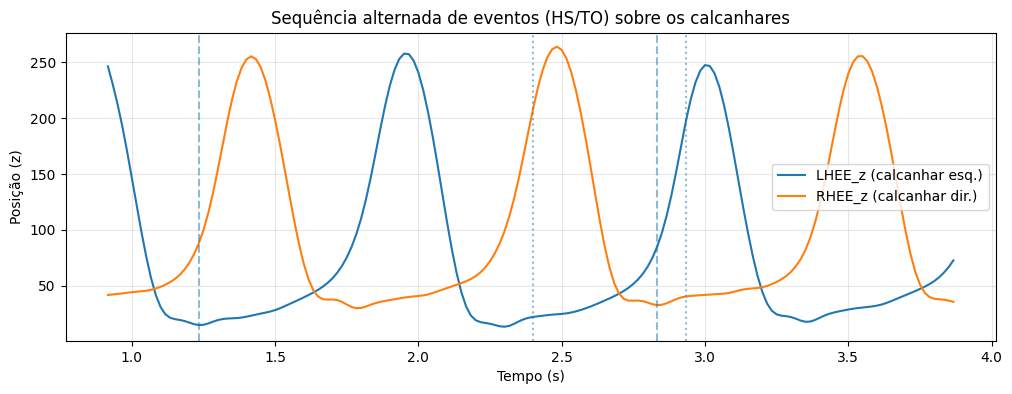

In [345]:
# ===== Visualização limpa da sequência alternada =====
# Para não "poluir" o gráfico, vamos plotar apenas os calcanhares (LHEE_z e RHEE_z)
heel_z_L = df_use["LHEE_z"].to_numpy()
heel_z_R = df_use["RHEE_z"].to_numpy()

plt.figure(figsize=(12,4))
plt.plot(t, heel_z_L, label="LHEE_z (calcanhar esq.)")
plt.plot(t, heel_z_R, label="RHEE_z (calcanhar dir.)")

# linhas verticais: HS (tracejado) e TO (pontilhado)
for ev, side, idx in events_alt:
    if ev == "HS":
        plt.axvline(t[idx], linestyle="--", alpha=0.5)
    else:  # TO
        plt.axvline(t[idx], linestyle=":", alpha=0.5)

plt.xlabel("Tempo (s)")
plt.ylabel("Posição (z)")
plt.title("Sequência alternada de eventos (HS/TO) sobre os calcanhares")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


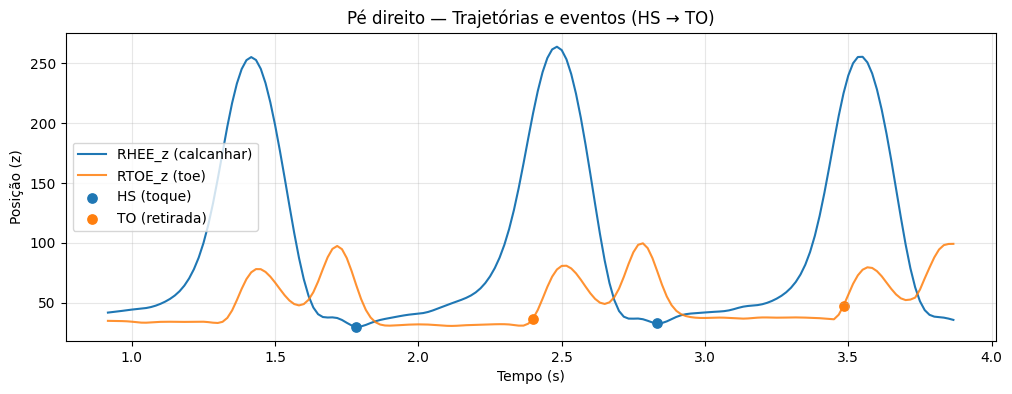

In [346]:
plt.figure(figsize=(12,4))

# trajetórias completas (continua igual)
plt.plot(t, heel_z_R, label="RHEE_z (calcanhar)")
plt.plot(t, toe_z_R,  label="RTOE_z (toe)", alpha=0.85)

# eventos PAREADOS (ordem fisiológica)
plt.scatter(
    t[paired_hs_R],
    heel_z_R[paired_hs_R],
    s=45,
    label="HS (toque)"
)

plt.scatter(
    t[paired_to_R],
    toe_z_R[paired_to_R],
    s=45,
    label="TO (retirada)"
)

plt.xlabel("Tempo (s)")
plt.ylabel("Posição (z)")
plt.title("Pé direito — Trajetórias e eventos (HS → TO)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


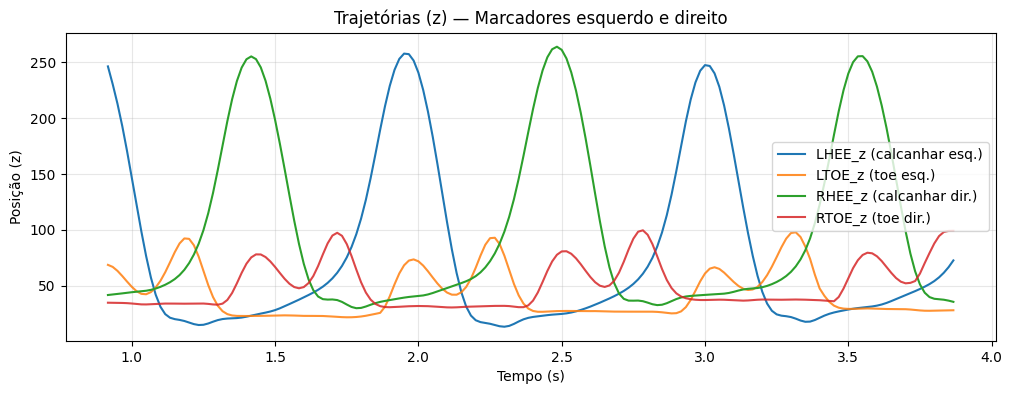

In [347]:
# esquerdo
heel_z_L = df_use["LHEE_z"].to_numpy()
toe_z_L  = df_use["LTOE_z"].to_numpy()

# direito
heel_z_R = df_use["RHEE_z"].to_numpy()
toe_z_R  = df_use["RTOE_z"].to_numpy()

plt.figure(figsize=(12,4))
plt.plot(t, heel_z_L, label="LHEE_z (calcanhar esq.)")
plt.plot(t, toe_z_L,  label="LTOE_z (toe esq.)", alpha=0.85)
plt.plot(t, heel_z_R, label="RHEE_z (calcanhar dir.)")
plt.plot(t, toe_z_R,  label="RTOE_z (toe dir.)", alpha=0.85)

plt.xlabel("Tempo (s)")
plt.ylabel("Posição (z)")
plt.title("Trajetórias (z) — Marcadores esquerdo e direito")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


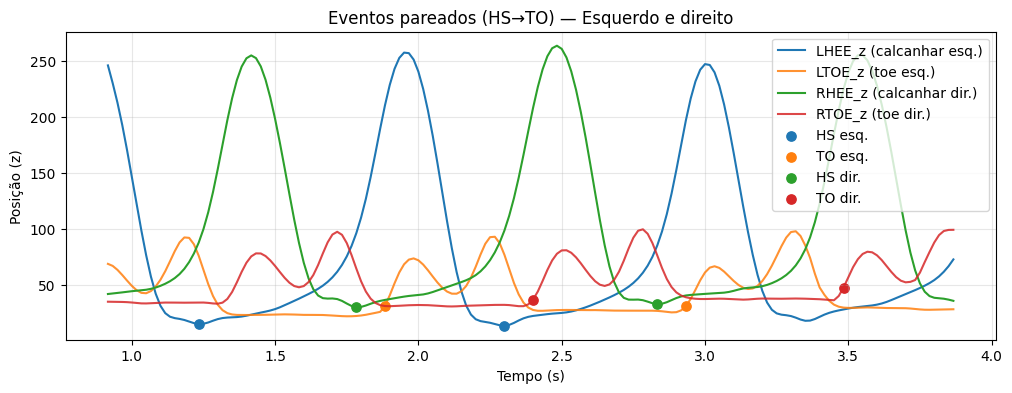

In [348]:
plt.figure(figsize=(12,4))

# curvas
plt.plot(t, heel_z_L, label="LHEE_z (calcanhar esq.)")
plt.plot(t, toe_z_L,  label="LTOE_z (toe esq.)", alpha=0.85)
plt.plot(t, heel_z_R, label="RHEE_z (calcanhar dir.)")
plt.plot(t, toe_z_R,  label="RTOE_z (toe dir.)", alpha=0.85)

# eventos ESQ (pareados)
plt.scatter(t[paired_hs], heel_z_L[paired_hs], s=45, label="HS esq.")
plt.scatter(t[paired_to], toe_z_L[paired_to], s=45, label="TO esq.")

# eventos DIR (pareados)
plt.scatter(t[paired_hs_R], heel_z_R[paired_hs_R], s=45, label="HS dir.")
plt.scatter(t[paired_to_R], toe_z_R[paired_to_R], s=45, label="TO dir.")

plt.xlabel("Tempo (s)")
plt.ylabel("Posição (z)")
plt.title("Eventos pareados (HS→TO) — Esquerdo e direito")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 7) Variáveis espaço-temporais (blocos didáticos)

A partir dos eventos detectados (**HS** e **TO**) podemos calcular variáveis clássicas da marcha.

**Convenções usadas aqui**
- HS = *heel strike* (toque do calcanhar no solo)
- TO = *toe-off* (retirada do pé do solo)
- Vamos calcular tudo com base no tempo `t` e nas posições (principalmente no eixo `x` para deslocamento para frente).

> Observação didática: estes cálculos são aproximações cinemáticas. Em estudos avançados, podem existir refinamentos
(filtragem, referência do laboratório, correção de direção do deslocamento, etc.).


### 7.1 Tempo de apoio (Stance time)

**O que é:** tempo em que o pé fica em contato com o solo.

**Como calculamos (por pé):**
- Para cada ciclo, `stance_time = t(TO) - t(HS)`

Ou seja, começamos no toque do calcanhar e terminamos na retirada do pé.


In [349]:
# tempos de apoio (s)
stance_L = t[paired_to_L] - t[paired_hs_L]
stance_R = t[paired_to_R] - t[paired_hs_R]

print("Stance (esq) - n:", len(stance_L), "| média:", np.mean(stance_L))
print("Stance (dir) - n:", len(stance_R), "| média:", np.mean(stance_R))


Stance (esq) - n: 2 | média: 0.641666666666665
Stance (dir) - n: 2 | média: 0.6333333333333349


### 7.2 Tempo de balanço (Swing time)

**O que é:** tempo em que o pé está no ar (sem contato), do toe-off até o próximo heel strike do mesmo pé.

**Como calculamos:**
- `swing_time = t(HS_próximo) - t(TO_atual)`

Para isso, precisamos de TOs pareados e do próximo HS (mesmo pé).


In [350]:
# swing: do TO até o próximo HS do mesmo pé
# (por isso usamos HS deslocado em 1 amostra em relação ao TO)
swing_L = t[paired_hs_L[1:]] - t[paired_to_L[:-1]] if len(paired_hs_L) > 1 else np.array([])
swing_R = t[paired_hs_R[1:]] - t[paired_to_R[:-1]] if len(paired_hs_R) > 1 else np.array([])

print("Swing (esq) - n:", len(swing_L), "| média:", np.mean(swing_L) if len(swing_L)>0 else np.nan)
print("Swing (dir) - n:", len(swing_R), "| média:", np.mean(swing_R) if len(swing_R)>0 else np.nan)


Swing (esq) - n: 1 | média: 0.41666666666666985
Swing (dir) - n: 1 | média: 0.43333333333333


### 7.3 Tempo de passada (Stride time)

**O que é:** tempo entre dois heel strikes consecutivos do **mesmo pé**.

**Como calculamos:**
- `stride_time = t(HS[i+1]) - t(HS[i])`


In [351]:
stride_time_L = np.diff(t[paired_hs_L]) if len(paired_hs_L) > 1 else np.array([])
stride_time_R = np.diff(t[paired_hs_R]) if len(paired_hs_R) > 1 else np.array([])

print("Stride time (esq) - n:", len(stride_time_L), "| média:", np.mean(stride_time_L) if len(stride_time_L)>0 else np.nan)
print("Stride time (dir) - n:", len(stride_time_R), "| média:", np.mean(stride_time_R) if len(stride_time_R)>0 else np.nan)


Stride time (esq) - n: 1 | média: 1.0666666666666698
Stride time (dir) - n: 1 | média: 1.0499999999999998


### 7.4 Tempo de passo (Step time)

**O que é:** tempo entre dois heel strikes consecutivos, alternando os pés (ex.: HS esquerdo → HS direito → HS esquerdo...).

**Como calculamos (simples):**
1. Juntamos todos os HS (esquerdo e direito) em uma única lista
2. Ordenamos por tempo
3. Calculamos a diferença entre eventos consecutivos

Isso gera uma sequência de tempos de passo.


In [352]:
# HS de cada pé (usamos hs_L_idx e hs_R_idx)
hs_events = []
for idx in hs_L_idx:
    hs_events.append(("L", idx))
for idx in hs_R_idx:
    hs_events.append(("R", idx))

# ordenar por tempo
hs_events = sorted(hs_events, key=lambda x: t[x[1]])

hs_times = np.array([t[i] for _, i in hs_events])
hs_sides = [s for s, _ in hs_events]

step_time_all = np.diff(hs_times) if len(hs_times) > 1 else np.array([])

print("Step time - n:", len(step_time_all), "| média:", np.mean(step_time_all) if len(step_time_all)>0 else np.nan)


Step time - n: 4 | média: 0.5291666666666675


### 7.5 Cadência (Cadence)

**O que é:** número de passos por minuto.

**Como calculamos:**
- Se `step_time` é o tempo médio de um passo (em segundos),
- então `cadence = 60 / mean(step_time)` (passos/minuto).


In [353]:
cadence = 60 / np.mean(step_time_all) if len(step_time_all)>0 else np.nan
print("Cadência (passos/min):", cadence)


Cadência (passos/min): 113.38582677165337


### 7.6 Comprimento da passada (Stride length)

**O que é:** distância percorrida entre dois HS consecutivos do mesmo pé.

**Como calculamos (aproximação em 1D):**
- usamos a posição `x` do calcanhar (`LHEE_x` e `RHEE_x`) nos instantes de HS.
- `stride_length = x(HS[i+1]) - x(HS[i])`

> Observação: usamos valor absoluto para não depender do sentido do eixo.


In [354]:
heel_x_L = df_use["LHEE_x"].to_numpy()
heel_x_R = df_use["RHEE_x"].to_numpy()

stride_len_L = np.abs(np.diff(heel_x_L[paired_hs_L])) if len(paired_hs_L) > 1 else np.array([])
stride_len_R = np.abs(np.diff(heel_x_R[paired_hs_R])) if len(paired_hs_R) > 1 else np.array([])

print("Stride length (esq) - n:", len(stride_len_L), "| média:", np.mean(stride_len_L) if len(stride_len_L)>0 else np.nan)
print("Stride length (dir) - n:", len(stride_len_R), "| média:", np.mean(stride_len_R) if len(stride_len_R)>0 else np.nan)


Stride length (esq) - n: 1 | média: 1401.064849853512
Stride length (dir) - n: 1 | média: 1389.460784912109


### 7.7 Comprimento do passo (Step length)

**O que é:** distância (aprox.) entre os pés no instante de um HS.

**Como calculamos (simples e didático):**
- no instante de um HS esquerdo, calculamos `|LHEE_x - RHEE_x|` naquele mesmo instante
- no instante de um HS direito, calculamos `|RHEE_x - LHEE_x|` naquele mesmo instante

Isso gera uma sequência alternada de comprimentos de passo.


In [355]:
# step length no instante do HS (aproximação didática)
step_len = []
step_side = []

for side, idx in hs_events:
    if side == "L":
        step_len.append(abs(heel_x_L[idx] - heel_x_R[idx]))
        step_side.append("L step")
    else:
        step_len.append(abs(heel_x_R[idx] - heel_x_L[idx]))
        step_side.append("R step")

step_len = np.array(step_len)

print("Step length - n:", len(step_len), "| média:", np.mean(step_len) if len(step_len)>0 else np.nan)


Step length - n: 5 | média: 653.6517578125024


### 7.8 Velocidade da marcha (Gait speed)

**O que é:** quão rápido a pessoa se desloca.

**Como calculamos (aproximação):**
- `speed ≈ stride_length_mean / stride_time_mean`

Vamos calcular a velocidade usando o pé esquerdo e o direito (e também uma média).


In [356]:
speed_L = (np.mean(stride_len_L) / np.mean(stride_time_L)) if (len(stride_len_L)>0 and len(stride_time_L)>0) else np.nan
speed_R = (np.mean(stride_len_R) / np.mean(stride_time_R)) if (len(stride_len_R)>0 and len(stride_time_R)>0) else np.nan
speed_mean = np.nanmean([speed_L, speed_R])

print("Velocidade (esq):", speed_L)
print("Velocidade (dir):", speed_R)
print("Velocidade (média):", speed_mean)


Velocidade (esq): 1313.4982967376636
Velocidade (dir): 1323.2959856305802
Velocidade (média): 1318.397141184122
